In [ ]:
!python -m pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 45.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("ppe-ihvqu").project("ppe-8k2vo")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-3 in yolov8:: 100%|██████████| 19948/19948 [00:03<00:00, 5077.29it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')
results = model.train(data='/content/PPE-3/data.yaml', epochs=50, imgsz=640)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PPE-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

### 1. Kết nối với Google Drive

In [ ]:
from google.colab import drive
import os
import shutil

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Tạo thư mục và lưu kết quả


In [ ]:
!python -m pip install ultralytics roboflow

In [32]:
from google.colab import drive
import os
from roboflow import Roboflow
from ultralytics import YOLO

drive.mount('/content/drive')

rf = Roboflow(api_key="X4Ws8QbGzfp3TT66Lkoi")
project = rf.workspace("ppe-ihvqu").project("ppe-8k2vo")
version = project.version(3)
dataset = version.download("yolov8")

yaml_path = os.path.join(dataset.location, "data.yaml")
weight_path = '/content/drive/MyDrive/YOLOv8_PPE_Results/train_experiment/weights/best.pt'

model = YOLO(weight_path)
metrics = model.val(data=yaml_path)

print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"mAP50: {metrics.box.map50:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loading Roboflow workspace...
loading Roboflow project...
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1768.3±617.9 MB/s, size: 51.6 KB)
val: Scanning /content/PPE-3/valid/labels.cache... 905 images, 16 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 905/905 271.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 57/57 5.1it/s 11.3s
                   all        905       3819      0.648      0.631      0.642      0.489
                Gloves        319        535      0.804      0.716      0.781      0.623
               Goggles        360        418      0.716      0.772      0.769      0.585
                Helmet        421      


image 1/1 /content/PPE-3/test/images/Screenshot-2025-06-17-172123_png.rf.84f34e05b1cd24fe561cee7eb65b1119.jpg: 640x640 5 Helmets, 8 Persons, 7.2ms
Speed: 1.7ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/PPE-3/test/images/Nein4500_jpg.rf.bc1489cae4bd0d45d414ecc403fb9f08.jpg: 640x640 (no detections), 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/PPE-3/test/images/Photin1167_jpg.rf.e2028456a9128ab6703f02e0f5bff33f.jpg: 640x640 1 No-Gloves, 1 Person, 7.2ms
Speed: 1.5ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/PPE-3/test/images/78_JPG_jpg.rf.acf14cb971fdf051337bf086748153de.jpg: 640x640 1 Goggles, 1 Helmet, 1 Person, 7.2ms
Speed: 2.0ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


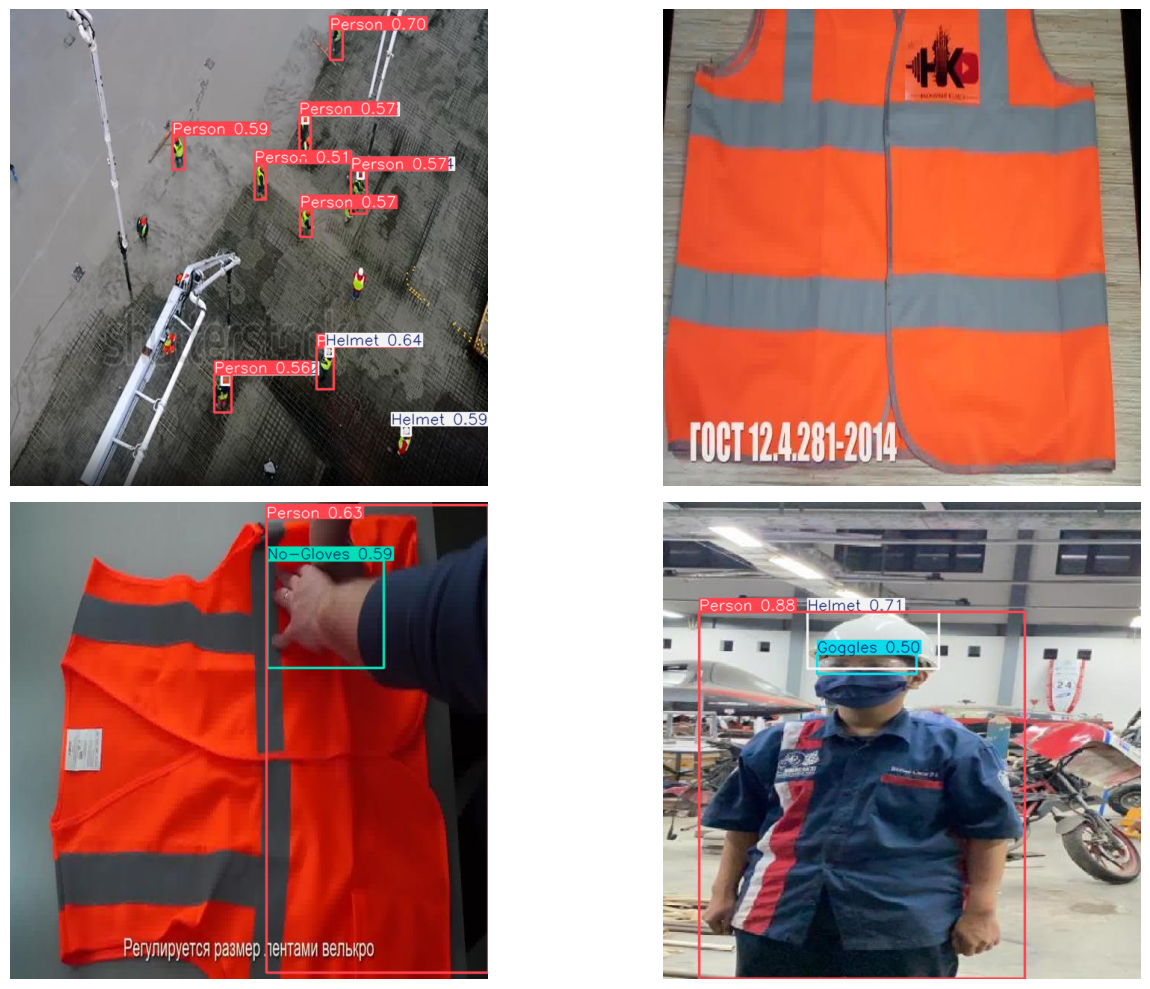

In [33]:
import glob
import cv2
import matplotlib.pyplot as plt

test_images = glob.glob(f'{dataset.location}/test/images/*.jpg')[:4]

plt.figure(figsize=(15, 10))
for i, img_path in enumerate(test_images):
    results = model.predict(source=img_path, conf=0.5, save=False)
    res_plotted = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i+1)
    plt.imshow(res_plotted)
    plt.axis('off')

plt.tight_layout()
plt.show()

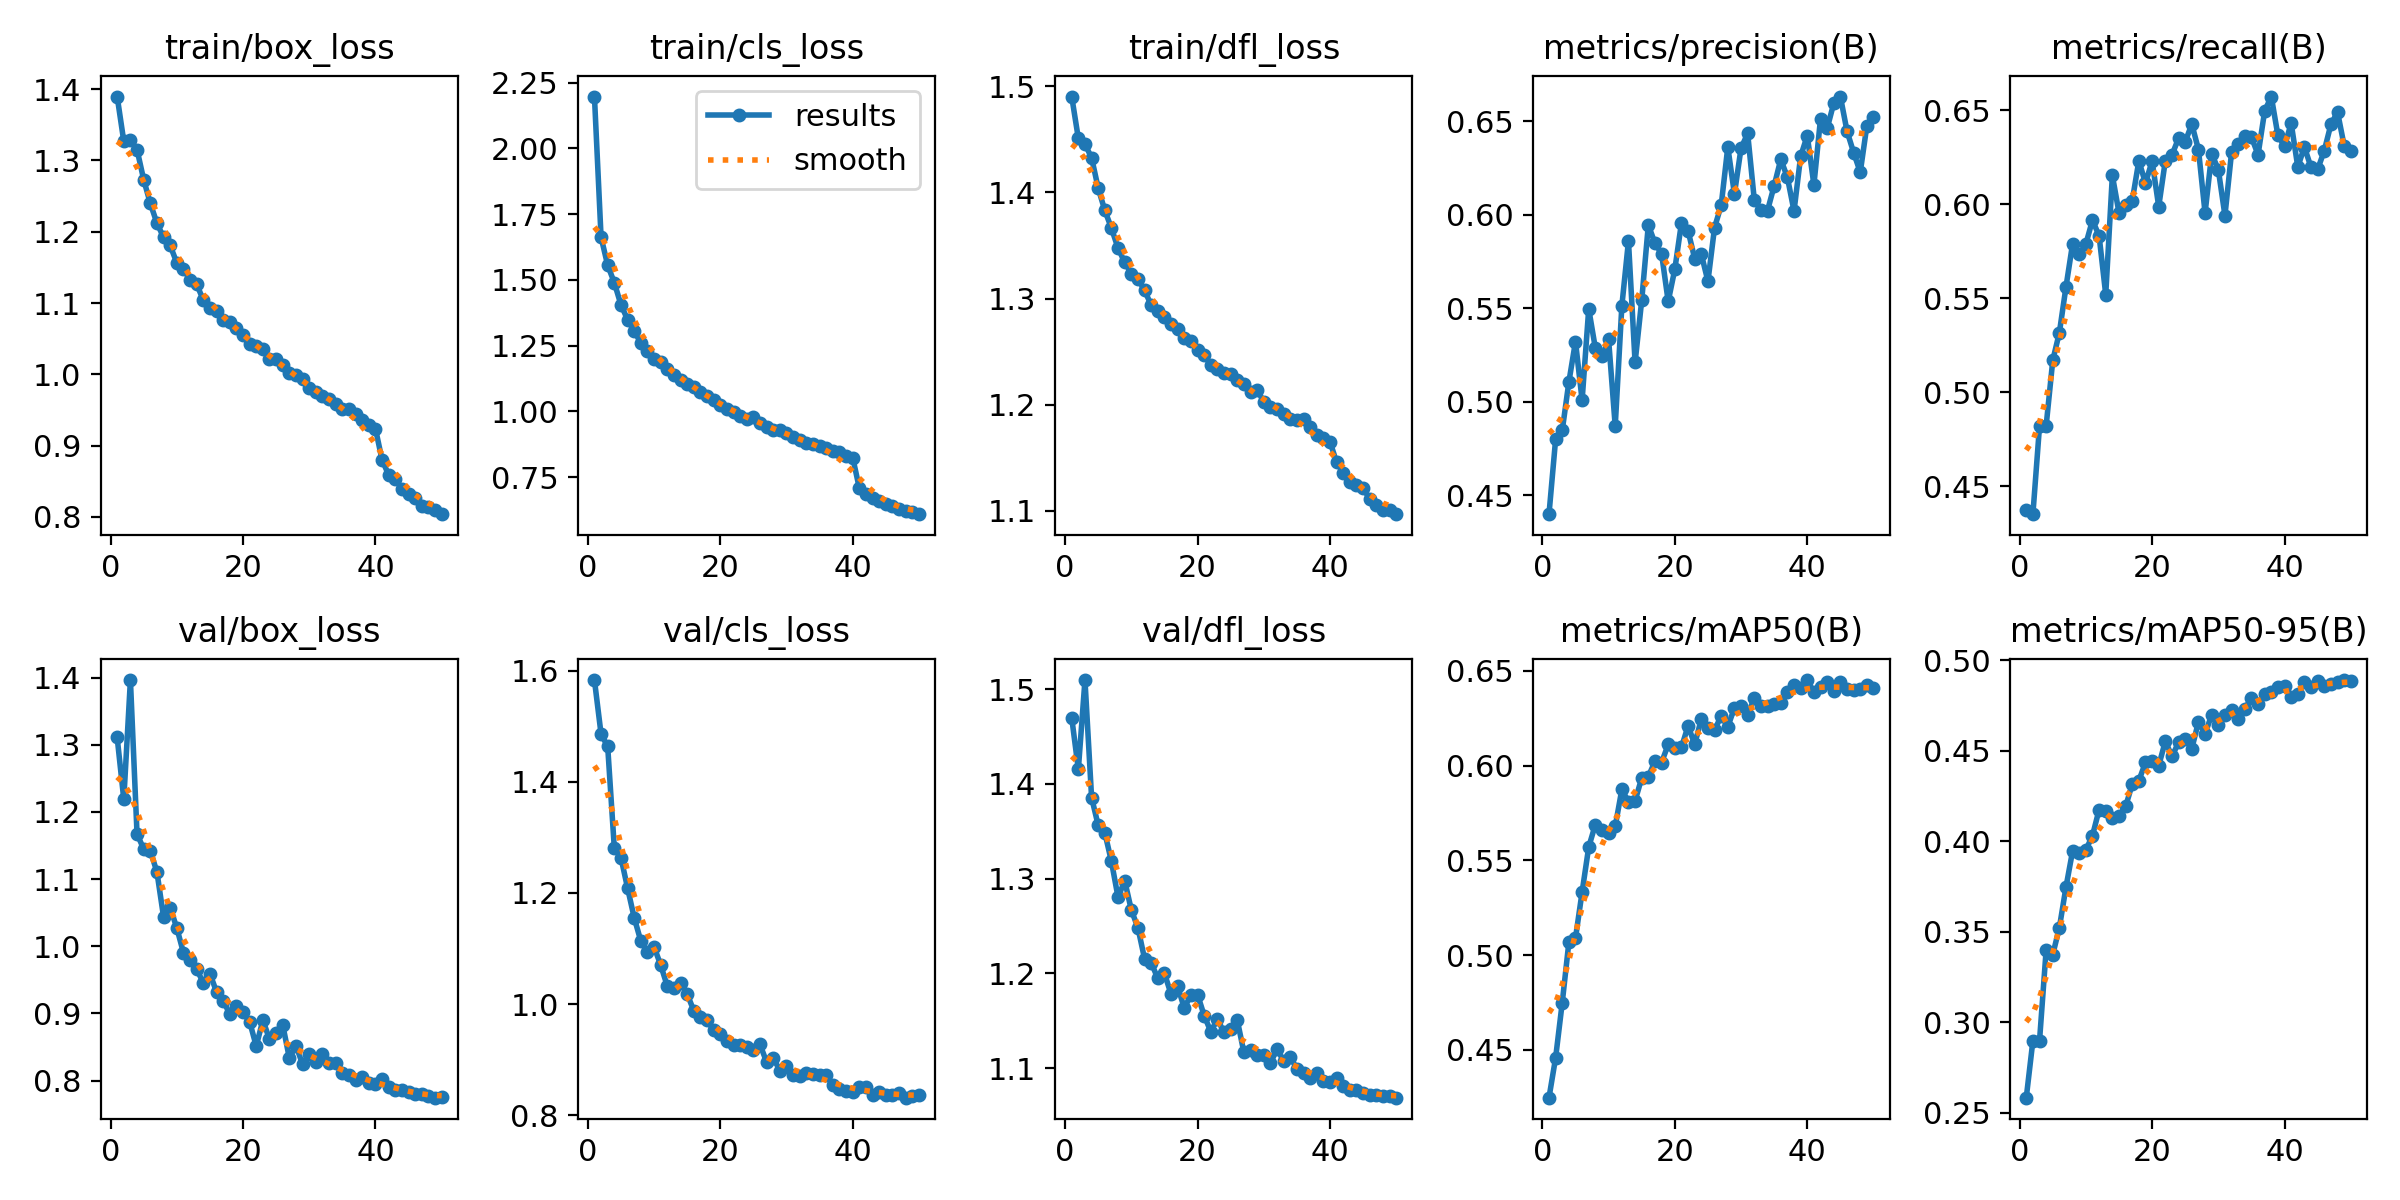

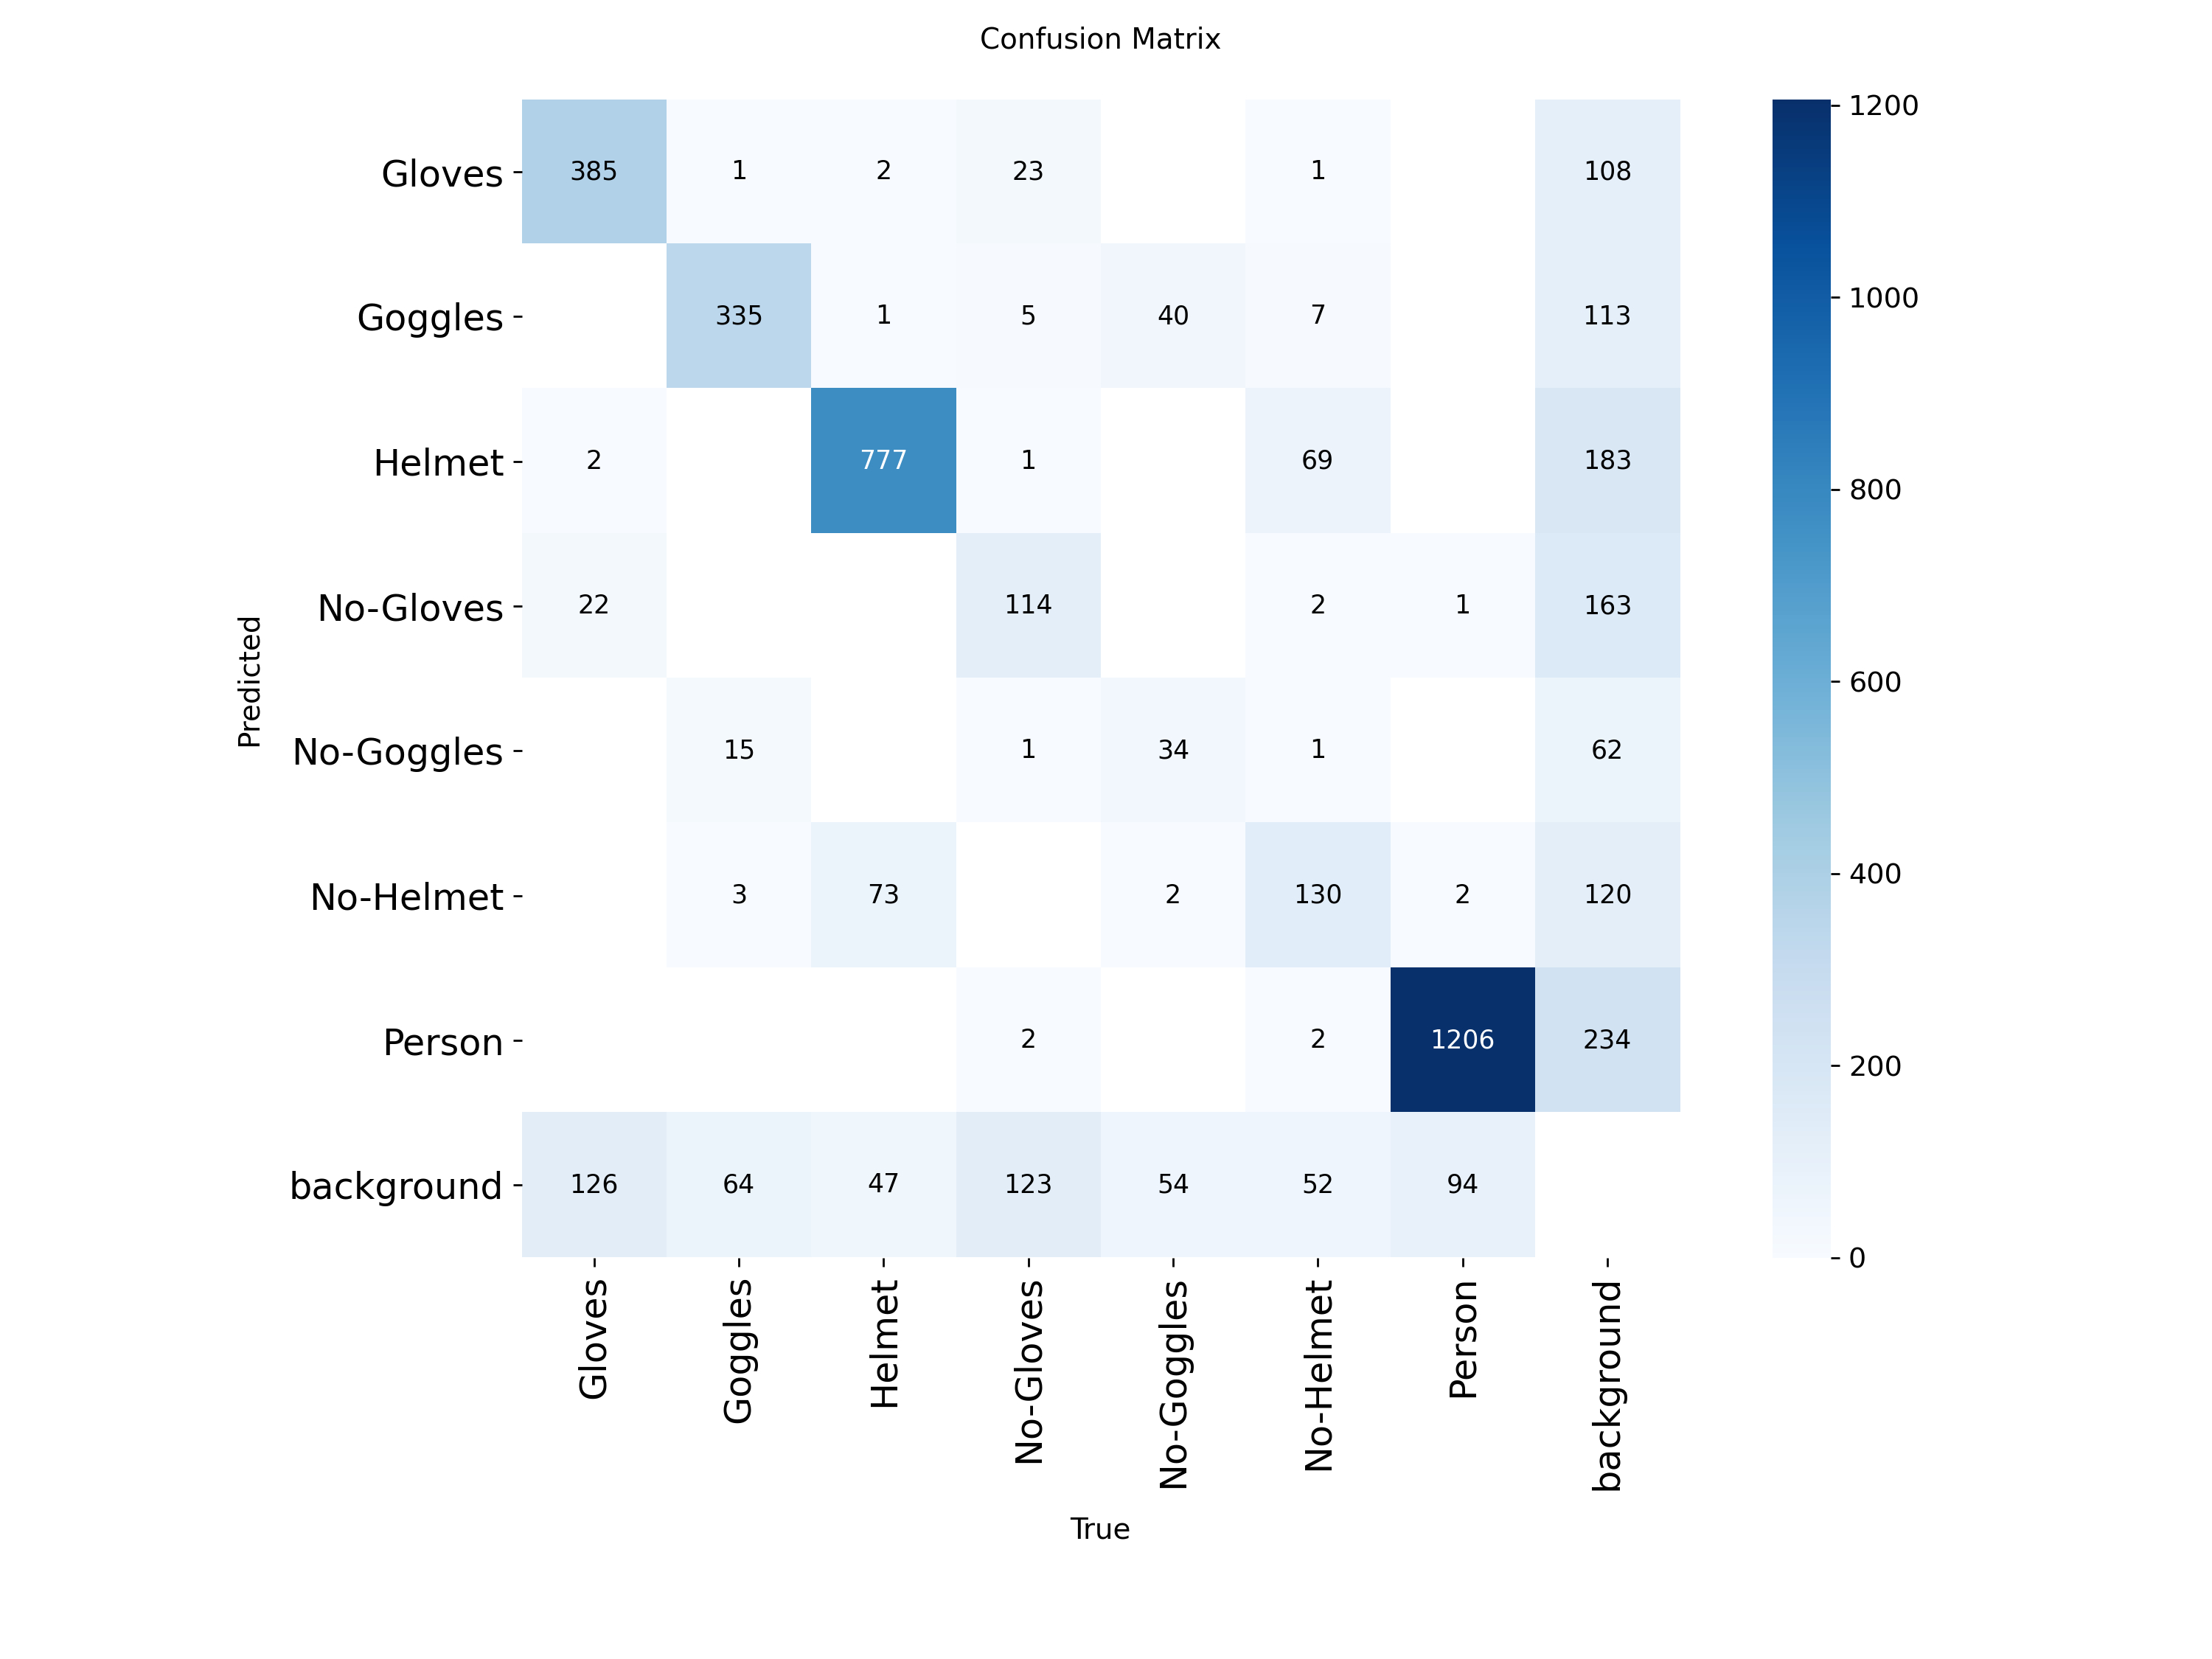

In [ ]:
import os
from IPython.display import display, Image

drive_results_dir = '/content/drive/MyDrive/YOLOv8_PPE_Results/train_experiment'

if os.path.exists(f'{drive_results_dir}/results.png'):
    display(Image(filename=f'{drive_results_dir}/results.png', width=1000))

if os.path.exists(f'{drive_results_dir}/confusion_matrix.png'):
    display(Image(filename=f'{drive_results_dir}/confusion_matrix.png', width=800))

if os.path.exists(f'{drive_results_dir}/PR_curve.png'):
    display(Image(filename=f'{drive_results_dir}/PR_curve.png', width=800))


image 1/1 /content/PPE-3/test/images/Screenshot-2025-06-17-172123_png.rf.84f34e05b1cd24fe561cee7eb65b1119.jpg: 640x640 6 Helmets, 9 Persons, 9.0ms
Speed: 1.9ms preprocess, 9.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/PPE-3/test/images/Nein4500_jpg.rf.bc1489cae4bd0d45d414ecc403fb9f08.jpg: 640x640 (no detections), 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/PPE-3/test/images/Photin1167_jpg.rf.e2028456a9128ab6703f02e0f5bff33f.jpg: 640x640 1 No-Gloves, 1 Person, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/PPE-3/test/images/78_JPG_jpg.rf.acf14cb971fdf051337bf086748153de.jpg: 640x640 1 Goggles, 1 Helmet, 1 Person, 7.2ms
Speed: 1.6ms preprocess, 7.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


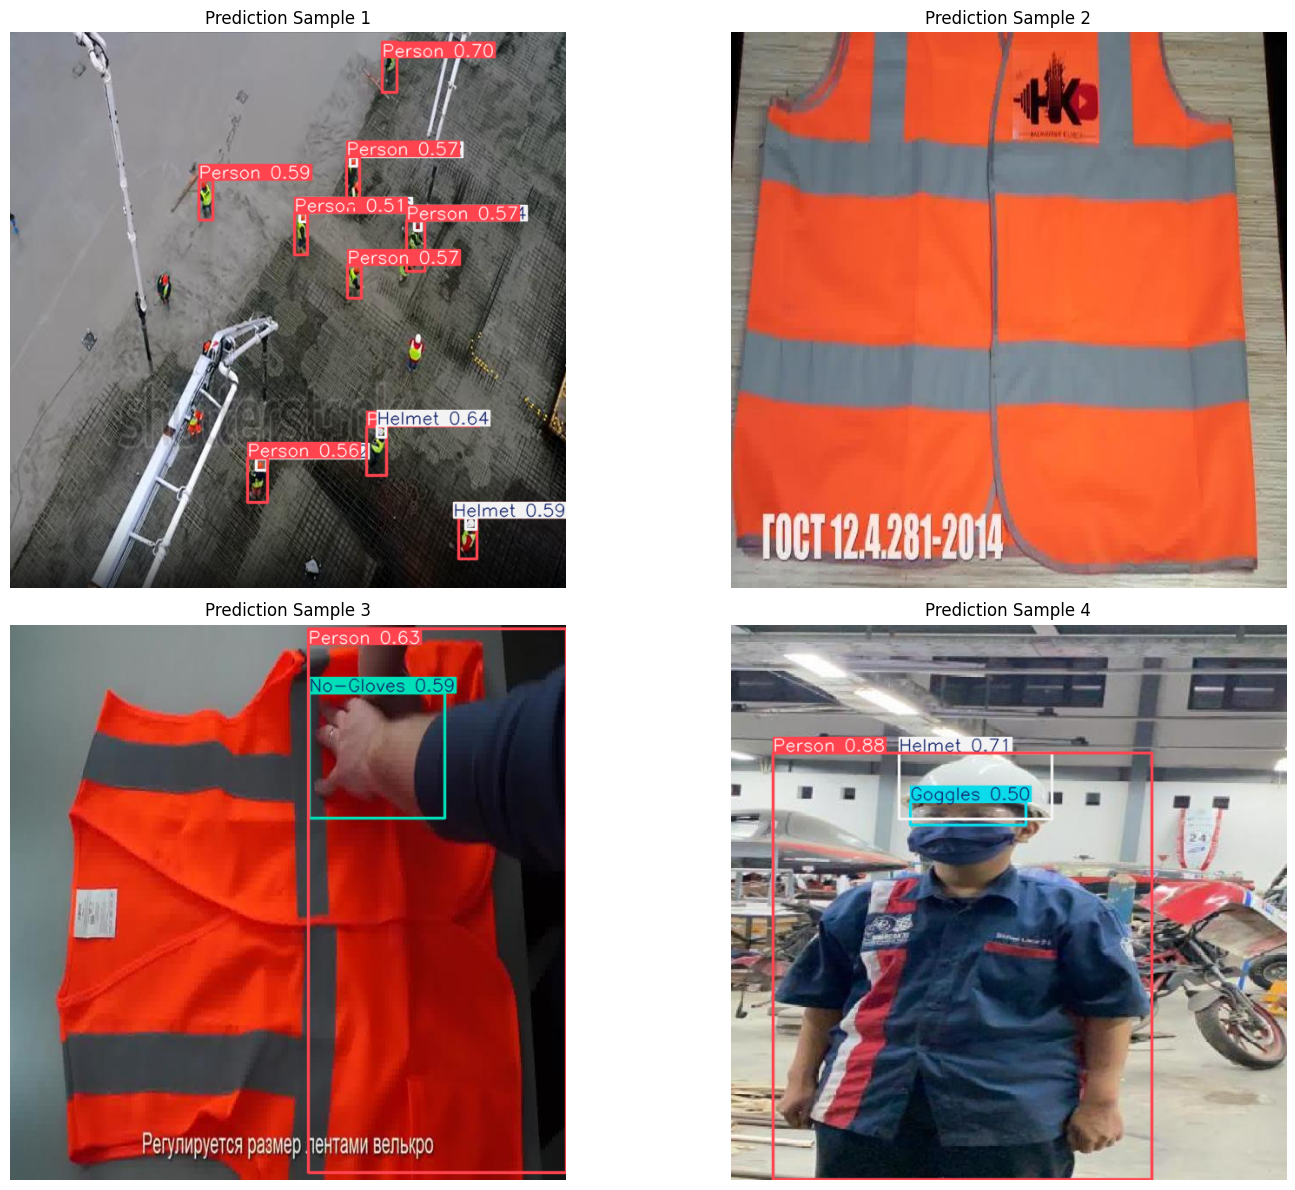


📝 MODEL STRENGTHS & LIMITATIONS ANALYSIS:
1. Strengths: The model accurately detects clear objects such as persons, hard hats, and safety vests in well-lit conditions, reflecting the high mAP50 score.
2. Limitations: Errors (False Negatives or False Positives) occur with small or distant objects, partial occlusions, or in low-light environments like dark corners of construction sites.


In [ ]:
import glob
import cv2  
import matplotlib.pyplot as plt
from ultralytics import YOLO

best_weight_path = '/content/drive/MyDrive/YOLOv8_PPE_Results/train_experiment/weights/best.pt'
evaluated_model = YOLO(best_weight_path)

sample_test_images = glob.glob('/content/PPE-3/test/images/*.jpg')[:4]

plt.figure(figsize=(16, 12))
for i, img_path in enumerate(sample_test_images):

    prediction_results = evaluated_model.predict(source=img_path, conf=0.4, save=False)
    annotated_img = cv2.cvtColor(prediction_results[0].plot(), cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i+1)
    plt.imshow(annotated_img)
    plt.title(f"Prediction Sample {i+1}")  
    plt.axis('off')

plt.tight_layout()
plt.show()

print("\n📝 MODEL STRENGTHS & LIMITATIONS ANALYSIS:")
print("1. Strengths: The model accurately detects clear objects such as persons, hard hats, and safety vests in well-lit conditions, reflecting the high mAP50 score.")
print("2. Limitations: Errors (False Negatives or False Positives) occur with small or distant objects, partial occlusions, or in low-light environments like dark corners of construction sites.")